In [ ]:
# --- Standard library ---
import warnings
import numpy as np
import pandas as pd
from pathlib import Path
from scipy.stats import ks_2samp
from collections import Counter

# --- Geospatial libraries ---
import geopandas as gpd
from shapely.ops import unary_union, polygonize
from shapely.geometry import Point, MultiPoint, LineString, box, MultiPolygon

# --- Clustering and machine learning ---
import hdbscan
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, r2_score, mean_squared_error
from scipy.optimize import curve_fit

# --- Plotting ---
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

# --- Matplotlib specific tools ---
from matplotlib import rcParams
from matplotlib import cm, colors as mcolors
import matplotlib.patches as mpatches
import matplotlib.patheffects as path_effects
from matplotlib.patches import PathPatch, Patch
from matplotlib.path import Path as mPath
from matplotlib.lines import Line2D
from matplotlib_scalebar.scalebar import ScaleBar

# Global rcParams for presentation-style visuals
rcParams.update({
    'axes.labelsize': 18,
    'axes.titlesize': 22,
    'axes.titleweight': 'bold',
    'axes.titlepad': 15,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 14,
    'legend.title_fontsize': 16,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial'],
    'font.size': 16,
    'figure.figsize': (12, 8),
    'axes.linewidth': 0.8,
    'axes.edgecolor': 'gray',
    'grid.linestyle': '--',
    'grid.alpha': 0.3,
    'axes.grid': False
})

def describe_clusters(df, cluster_col, X=None, geo_col='geometry'):
    labels = df[cluster_col]
    unique_clusters = set(labels)
    n_clusters = len(unique_clusters) - (1 if -1 in unique_clusters else 0)
    n_noise = list(labels).count(-1)
    total_points = len(df)
    clustered_points = total_points - n_noise

    print(f"📊 Number of clusters (excluding noise): {n_clusters}")
    print(f"✅ Clustered points: {clustered_points}")
    print(f"🔢 Noise points: {n_noise} / {total_points} ({n_noise/total_points:.2%})")

    # Cluster sizes
    cluster_counts = Counter(labels)
    # for cluster_id, count in sorted(cluster_counts.items()):
    #     label = f"Cluster {cluster_id}" if cluster_id != -1 else "Noise"
    #     print(f"  {label}: {count} points")

    # Prepare cluster summary table
    cluster_summary = []

    # Area calculation
    if isinstance(df, gpd.GeoDataFrame) and geo_col in df.columns:
        # print("\n📐 Cluster real-space area (approx. using convex hull):")
        for cluster_id in sorted(unique_clusters):
            if cluster_id == -1:
                continue  # skip noise
            cluster_points = df[df[cluster_col] == cluster_id][geo_col]
            multipoint = MultiPoint(cluster_points.values)

            if multipoint.is_empty or len(multipoint.geoms) < 3:
                area_m2 = 0
            else:
                hull = multipoint.convex_hull
                area_m2 = hull.area

            area_km2 = area_m2 / 1e6
            n_points = cluster_counts[cluster_id]

            # print(f"  Cluster {cluster_id}: {area_m2:,.0f} m² ({area_km2:.3f} km²)")

            cluster_summary.append({
                'cluster_id': cluster_id,
                'n_points': n_points,
                'area_m2': area_m2,
                'area_km2': area_km2
            })

    # Silhouette Score - exclude noise points (-1)
    sil_score = None
    if X is not None:
        mask = labels != -1
        X_valid = X[mask]
        labels_valid = labels[mask]

        n_valid_clusters = len(set(labels_valid))
        if n_valid_clusters > 1:
            try:
                sil_score = silhouette_score(X_valid, labels_valid)
                print(f"📈 Silhouette Score (excluding noise): {sil_score:.3f}")
            except Exception as e:
                print(f"\n⚠️  Silhouette Score could not be calculated: {e}")
        else:
            print("\nℹ️  Silhouette Score skipped (less than 2 valid clusters after excluding noise).")
    else:
        print("\nℹ️  Silhouette Score skipped (no feature matrix X provided).")

    cluster_summary_df = pd.DataFrame(cluster_summary)
    return cluster_summary_df, sil_score

projected_crs = "EPSG:32737"
DATA_DIR = Path('/Users/wenlanzhang/Downloads/PhD_UCL/Data/Waste/')

In [ ]:
# # from scipy.optimize import curve_fit
# # import numpy as np
# # import matplotlib.pyplot as plt
# # import seaborn as sns
# from scipy.optimize import curve_fit
# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns

# 1. Load Data

## Load SVI 

In [ ]:
AllSVI_df = pd.read_csv("/Users/wenlanzhang/Downloads/PhD_UCL/Data/Waste/img/Combined_SVI.csv", low_memory=False)
AllSVI_df = AllSVI_df[(AllSVI_df['img_dir'] != 'ZWL/') & (AllSVI_df['img_dir'] != 'Faith/')]
AllSVI_df = AllSVI_df.drop(columns=['month', 'day', 'hour', 'exist', 'yolo_conf', 'yolo_bbox', 'yolo_num', 'prediction', 'Construction'])
AllSVI_df = AllSVI_df.drop_duplicates(subset=['lat', 'lon', 'img_name'], keep='first')

# year: 2018, 2021, 2022, 2017

# Add geometry column (make sure lon/lat exist)
AllSVI_df['geometry'] = AllSVI_df.apply(lambda row: Point(row['lon'], row['lat']), axis=1)
AllSVI_gdf = gpd.GeoDataFrame(AllSVI_df, geometry='geometry', crs="EPSG:4326")
AllSVI_gdf = AllSVI_gdf.to_crs(projected_crs)
AllSVI_gdf

## Load waste 

In [ ]:
waste_df = pd.read_csv("/Users/wenlanzhang/Downloads/PhD_UCL/Data/Waste/img/Correct_SVI.csv")
waste_df = waste_df[(waste_df['img_dir'] != 'ZWL/') & (waste_df['img_dir'] != 'Faith/')]
waste_df = waste_df.drop(columns=['year', 'month', 'day', 'hour', 'exist', 'yolo_conf', 'yolo_bbox', 'yolo_num', 'prediction', 'Construction'])
waste_df = waste_df.drop_duplicates(subset=['lat', 'lon', 'img_name'], keep='first')
# year: 2018, 2021, 2022, 2017

# Add geometry column (make sure lon/lat exist)
waste_df['geometry'] = waste_df.apply(lambda row: Point(row['lon'], row['lat']), axis=1)
waste_gdf = gpd.GeoDataFrame(waste_df, geometry='geometry', crs="EPSG:4326")
waste_gdf = waste_gdf.to_crs(projected_crs)
waste_gdf

## Load Nairobi boundary shapefile

1个框外 + 35没有坐标
- Original count: 4082
- Clipped count: 4046
- Removed count: 36
- Cliped within Nairobi count: 3385

In [ ]:
boundary = gpd.read_file("/Users/wenlanzhang/Downloads/PhD_UCL/Data/Shp/NariobiShp/Shp_from_Constituency/Nairobi_shp_C.shp")
boundary = boundary.drop(columns=['country', 'provpcode', 'province', 'ctypcode', 'county', 'scpcode', 
                      'subcounty', 'dhis2_id'])
boundary = boundary.to_crs(projected_crs)
boundary

## Load Slum shapefile

In [ ]:
slums_grid_gdf = gpd.read_file("/Users/wenlanzhang/Downloads/PhD_UCL/Data/Waste/Angela/slumaps_nairobi_sett/slumaps_nairobi_sett.shp")
slums_grid_gdf = slums_grid_gdf[['geometry', 'score']].to_crs(projected_crs)
# slums_grid_gdf

# Combine into one slum boundary (dissolve to merge polygons)
slum_area_polygon = slums_grid_gdf.union_all()
slums_gdf = gpd.GeoDataFrame(geometry=[slum_area_polygon], crs=slums_grid_gdf.crs)
slums_gdf

## Yolo Detection result 

In [ ]:
df = pd.read_csv("/Users/wenlanzhang/Downloads/PhD_UCL/Data/Waste/img/yolo_Google.csv")
df = df[(df['img_dir'] != 'ZWL/') & (df['img_dir'] != 'Faith/')]

df['geometry'] = df.apply(lambda row: Point(row['lon'], row['lat']), axis=1)
gdf = gpd.GeoDataFrame(df, geometry='geometry', crs="EPSG:4326")
gdf = gdf.to_crs(projected_crs)


gdf = gpd.clip(gdf, boundary)
# gdf

len(gdf[gdf['yolo_conf'] != '[]'])/len(gdf)

# Yolo Detedted number

## Clip to Nairobi

In [ ]:
# Perform spatial intersection (keeps only overlapping geometries)
slums_Nairobi_gdf = gpd.overlay(slums_gdf, boundary, how='intersection')
# slums_Nairobi_gdf

# Clip fly-tipping points inside city boundary
waste_Nairobi_gdf = gpd.clip(waste_gdf, boundary)
coords = np.array(list(zip(waste_Nairobi_gdf.geometry.x, waste_Nairobi_gdf.geometry.y)))
# waste_Nairobi_gdf

# Clip fly-tipping points inside city boundary
ALLSVI_Nairobi_gdf = gpd.clip(AllSVI_gdf, boundary)
ALLSVI_Nairobi_gdf

In [ ]:
ALLSVI_Nairobi_gdf[ALLSVI_Nairobi_gdf['Domestic'] == 'Y']
# ALLSVI_Nairobi_gdf['Domestic'].unique()
# waste_Nairobi_gdf

In [ ]:
ALLSVI_Nairobi_gdf

###  Bar char of Nairobi SVI image

In [ ]:
# Count unique panoramas per year
year_counts = (
    ALLSVI_Nairobi_gdf_unique.groupby('year')
    .size()
    .reset_index(name='count')
    .sort_values('year')
)

# Choose your favorite color
color = "#e4c8b0"   # e.g. "tomato", "#2E86AB", "forestgreen", "orange"

# Plot
plt.figure(figsize=(8, 5))
ax = sns.barplot(
    data=year_counts,
    x='year',
    y='count',
    color=color
)

# Add count labels on top of bars
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height()):,}',   # <-- adds commas (e.g., 12,345)
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='bottom',
        fontsize=11
    )

plt.xlabel("Year")
plt.ylabel("Number of Street View Images")
plt.title("Number of Street View Images per Year")

plt.savefig(DATA_DIR / 'Figure/SVIperYear.png', dpi=600, bbox_inches='tight', transparent=True)

plt.tight_layout()
plt.show()

In [ ]:
# Count unique panoramas per year
year_counts = (
    ALLSVI_Nairobi_gdf_unique.groupby('year')
    .size()
    .reset_index(name='count')
    .sort_values('year')
)

# Choose colour
color = "#e4c8b0"

# Plot
fig, ax = plt.subplots(figsize=(8, 5))

sns.barplot(
    data=year_counts,
    x='year',
    y='count',
    color=color,
    edgecolor="#4a4a4a",
    linewidth=0.8,
    ax=ax
)

# Add count labels
for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f'{int(height):,}',
        (p.get_x() + p.get_width() / 2, height),
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold',
        xytext=(0, 4),
        textcoords='offset points'
    )

# Labels and title
ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Number of Street View Images", fontsize=12)
ax.set_title(
    "Number of Street View Images per Year",
    fontsize=14,
    fontweight='bold',
    pad=15
)

# Make y-axis use commas too
ax.yaxis.set_major_formatter(lambda x, pos: f'{int(x):,}')

# Cleaner style
# sns.despine()
ax.grid(axis='y', linestyle='--', alpha=0.35)
ax.set_axisbelow(True)

# Tick style
ax.tick_params(axis='x', labelsize=11)
ax.tick_params(axis='y', labelsize=11)

plt.tight_layout()

plt.savefig(
    DATA_DIR / 'Figure/SVIperYear.png',
    dpi=600,
    bbox_inches='tight',
    transparent=True
)

plt.show()

In [ ]:
306420/4

In [ ]:
3236/306420

In [ ]:
3236/13257

# Area Percentage

In [ ]:
# Compute the percentage
total_slums = len(slums_gdf)
slums_within = len(slums_Nairobi_gdf)

percentage = (slums_within / total_slums) * 100

print(f"{slums_within} of {total_slums} slum features intersect the boundary.")
print(f"That's {percentage:.2f}% of slums.")

In [ ]:
# Convert LINESTRING slums to polygon
merged_lines = unary_union(slums_gdf.geometry)
slum_polygons = list(polygonize(merged_lines))
slum_areas_gdf = gpd.GeoDataFrame(geometry=slum_polygons, crs=projected_crs)

# Calculate areas
slum_area = slums_Nairobi_gdf.geometry.area.sum()
city_area = boundary.union_all().area
slum_pct = (slum_area / city_area) * 100
# slum_area_total = slum_areas_gdf.geometry.area.sum()  # in square meters

print(f"Slum area: {slum_area/1e6:.2f} km²")
print(f"City area: {city_area/1e6:.2f} km²")
# print(f"Slum area: {slum_area / 1e6:.2f} km² ({slum_pct:.2f}%)")
print(f"Slums cover approximately {slum_pct:.2f}% of the city.")

In [ ]:
19.86/695.1

# Visulisation

In [ ]:
# Spatial join: Find fly-tipping incidents inside slums
waste_Nairobi_gdf = waste_Nairobi_gdf.to_crs(projected_crs)
slums_grid_gdf = slums_grid_gdf.to_crs(projected_crs)
waste_in_slums = gpd.sjoin(waste_Nairobi_gdf, slums_grid_gdf, how="inner", predicate="within")
waste_in_slums = waste_in_slums.to_crs(projected_crs)

waste_in_slums

In [ ]:
# Project to UTM Zone 37S
boundary_4326 = boundary.to_crs(epsg=4326)
waste_4326 = waste_Nairobi_gdf.to_crs(epsg=4326)
slums_4326 = slums_Nairobi_gdf.to_crs(epsg=4326)

# Stats

## !!!! ADD NNR?  

## PCR (Proportional Cluster Ratio)
Proportion of total area: Proportion of area occupied by slums = city area / slum area   
PCR: PCR = Proportion of total area / Proportion of incidents in area

Proportion of incidents in the area  = fly_tipping_in_slums / waste_Nairobi_gdf  
PCR = Proportion of incidents in the area / Proportion of total area

In [ ]:
len(waste_in_slums) / len(waste_Nairobi_gdf) / (slum_area / city_area)

## Per area density (11.19 in m²)

In [ ]:
# # ------------- Per area density (in m²) -------------

# # Area of slum polygons
# slum_area = slums_Nairobi_gdf.union_all().area  # in square meters
# total_area = waste_Nairobi_gdf.total_bounds  # [minx, miny, maxx, maxy]
# bbox = gpd.GeoSeries([box(*total_area)], crs=waste_Nairobi_gdf.crs)
# non_slum_area = bbox.difference(slums_Nairobi_gdf.union_all()).area[0]

# # Number of points
# points_inside = len(waste_in_slums)
# points_total = len(waste_Nairobi_gdf)
# points_outside = points_total - points_inside

# # Densities
# density_inside = points_inside / slum_area
# density_outside = points_outside / non_slum_area

# print(f"Density inside slums: {density_inside:.9f} points/m²")
# print(f"Density outside slums: {density_outside:.9f} points/m²")

# print(f"Slum area: {slum_area / 1e6:.2f} km²")
# print(f"Non-slum area: {non_slum_area / 1e6:.2f} km²")
# density_ratio = density_inside / density_outside

# print(f"The density inside slums is approximately {density_ratio:.2f} times higher than outside.")

In [ ]:
# ------------- Slum area (UNCHANGED) -------------
slum_area = slums_Nairobi_gdf.union_all().area  # keep exactly as you had it

# ------------- City boundary (FIXED) -------------
# Use a proper boundary polygon (NOT waste bounding box)
city_geom = boundary.union_all()
city_area = city_geom.area

# ------------- Non-slum area (FIXED) -------------
# non-slum = city minus slums
non_slum_geom = city_geom.difference(slums_Nairobi_gdf.union_all())
non_slum_area = non_slum_geom.area

# ------------- Points -------------
points_inside = len(waste_in_slums)
points_total = len(waste_Nairobi_gdf)
points_outside = points_total - points_inside

# ------------- Densities -------------
density_inside = points_inside / slum_area
density_outside = points_outside / non_slum_area

# ------------- Outputs -------------
print(f"Slum area: {slum_area / 1e6:.2f} km²")
print(f"City area: {city_area / 1e6:.2f} km²")
print(f"Non-slum area: {non_slum_area / 1e6:.2f} km²")

slum_pct = (slum_area / city_area) * 100
print(f"Slums cover approximately {slum_pct:.2f}% of the city.")

density_ratio = density_inside / density_outside
print(f"Density inside slums: {density_inside:.9f} points/m²")
print(f"Density outside slums: {density_outside:.9f} points/m²")
print(f"The density inside slums is approximately {density_ratio:.2f} times higher than outside.")

## Per image density (4.65 waste points per SVI image)

In [ ]:
# ------------- Per image density (fly-tipping points per SVI image) ------------- 
''' it could reflect data availability rather than actual fly-tipping behavior.'''

# Ensure both point datasets use same CRS
waste_Nairobi_gdf = waste_Nairobi_gdf.to_crs(slums_Nairobi_gdf.crs)
ALLSVI_Nairobi_gdf = ALLSVI_Nairobi_gdf.to_crs(slums_Nairobi_gdf.crs)

# --- Count fly-tipping points in slums ---
waste_in_slums = gpd.sjoin(waste_Nairobi_gdf, slums_Nairobi_gdf, how='inner', predicate='within')
points_inside = len(waste_in_slums)
points_total = len(waste_Nairobi_gdf)
points_outside = points_total - points_inside

# --- Count SVI images in slums ---
images_in_slums = gpd.sjoin(ALLSVI_Nairobi_gdf, slums_Nairobi_gdf, how='inner', predicate='within')
images_inside = len(images_in_slums)
images_total = len(ALLSVI_Nairobi_gdf)
images_outside = images_total - images_inside

# --- Compute incident per image ratios ---
density_inside = points_inside / images_inside if images_inside else 0
density_outside = points_outside / images_outside if images_outside else 0

# --- Output ---
print(f"Fly-tipping incidents inside slums: {points_inside}")
print(f"SVI images inside slums: {images_inside}")
print(f"Incident density inside slums: {density_inside:.4f} incidents per image\n")

print(f"Fly-tipping incidents outside slums: {points_outside}")
print(f"SVI images outside slums: {images_outside}")
print(f"Incident density outside slums: {density_outside:.4f} incidents per image\n")

# Ratio
if density_outside > 0:
    density_ratio = density_inside / density_outside
    print(f"Slum incident/image density is {density_ratio:.2f} times higher than outside.")
else:
    print("Cannot compute ratio: zero images outside slums.")

# Table 1

In [ ]:
import geopandas as gpd
import pandas as pd

# =========================================================
# 1. GEOMETRIES (CONSISTENT FRAMEWORK)
# =========================================================

city_geom = boundary.union_all()
slum_geom = slums_Nairobi_gdf.union_all()
non_slum_geom = city_geom.difference(slum_geom)

slum_area_km2 = slum_geom.area / 1e6
non_slum_area_km2 = non_slum_geom.area / 1e6
city_area_km2 = city_geom.area / 1e6


# =========================================================
# 2. POINT COUNTS (FLY-TIPPING)
# =========================================================

waste_Nairobi_gdf = waste_Nairobi_gdf.to_crs(slums_Nairobi_gdf.crs)

waste_in_slums = gpd.sjoin(
    waste_Nairobi_gdf, slums_Nairobi_gdf,
    how="inner", predicate="within"
)

points_inside = len(waste_in_slums)
points_total = len(waste_Nairobi_gdf)
points_outside = points_total - points_inside


# =========================================================
# 3. SVI COUNTS (DATA AVAILABILITY CHECK)
# =========================================================

ALLSVI_Nairobi_gdf = ALLSVI_Nairobi_gdf.to_crs(slums_Nairobi_gdf.crs)

images_in_slums = gpd.sjoin(
    ALLSVI_Nairobi_gdf, slums_Nairobi_gdf,
    how="inner", predicate="within"
)

images_inside = len(images_in_slums)
images_total = len(ALLSVI_Nairobi_gdf)
images_outside = images_total - images_inside


# =========================================================
# 4. DENSITIES (SPATIAL INTENSITY)
# =========================================================

# per area
density_inside_area = points_inside / slum_area_km2
density_outside_area = points_outside / non_slum_area_km2

density_ratio_area = (
    density_inside_area / density_outside_area
    if density_outside_area > 0 else None
)

# per image (important: data availability indicator)
density_inside_image = (
    (points_inside / images_inside) * 100 if images_inside > 0 else 0
)

density_outside_image = (
    (points_outside / images_outside) * 100 if images_outside > 0 else 0
)

density_ratio_image = (
    density_inside_image / density_outside_image
    if density_outside_image > 0 else None
)


# =========================================================
# 5. FINAL TABLE
# =========================================================

df_table = pd.DataFrame([
    {
        "Zone": "Urban poor",
        "Area (km²)": slum_area_km2,
        "Waste Piles (n)": points_inside,
        "Waste piles share (%)": (points_inside / points_total) * 100,
        "Density (per km²)": density_inside_area,
        "SVI images (n)": images_inside,
        "Density per SVI image (%)": density_inside_image
    },
    {
        "Zone": "Non-urban poor",
        "Area (km²)": non_slum_area_km2,
        "Waste Piles (n)": points_outside,
        "Waste piles share (%)": (points_outside / points_total) * 100,
        "Density (per km²)": density_outside_area,
        "SVI images (n)": images_outside,
        "Density per SVI image (%)": density_outside_image
    },
    {
        "Zone": "Urban poor / non ratio",
        "Area (km²)": None,
        "Waste Piles (n)": None,
        "Waste piles share (%)": None,
        "Density (per km²)": density_ratio_area,
        "SVI images (n)": None,
        "Density per SVI image (%)": density_ratio_image
    },
    {
        "Zone": "Total",
        "Area (km²)": city_area_km2,
        "Waste Piles (n)": points_total,
        "Waste piles share (%)": 100,
        "Density (per km²)": None,
        "SVI images (n)": images_total,
        "Density per SVI image (%)": None
    }
])

# round all numeric columns to 2 decimals
table_rounded = df_table.copy()

numeric_cols = table_rounded.select_dtypes(include="number").columns
table_rounded[numeric_cols] = table_rounded[numeric_cols].round(2)

table_rounded

In [ ]:
# Fit Nearest Neighbors to data
nbrs = NearestNeighbors(n_neighbors=5).fit(coords)
distances, indices = nbrs.kneighbors(coords)

# Sort distances for plotting
distances = np.sort(distances[:, 4])  # Use the 4th neighbor distance
plt.plot(distances)
plt.title("K-Nearest Neighbors Distance Plot")
plt.xlabel("Points sorted by distance")
plt.ylabel("Distance to 4th nearest neighbor")
plt.show()

# HDBSCAN

In [ ]:
# Initialize and fit HDBSCAN model
ncs = 25
ms = 6

# Ensure clipped_gdf is a copy to avoid SettingWithCopyWarning
waste_Nairobi_gdf = waste_Nairobi_gdf.copy()

# Initialize and fit HDBSCAN model
HDB_clusterer = hdbscan.HDBSCAN(
    min_cluster_size = ncs,
    min_samples = ms,
    # cluster_selection_epsilon=0.003,
    gen_min_span_tree=True 
)

# Assign clusters using .loc
waste_Nairobi_gdf.loc[:, "HDB_cluster"] = HDB_clusterer.fit_predict(coords)

# View cluster labels (-1 represents noise/outliers)
# print(clipped_gdf["HDB_cluster"].value_counts())
waste_Nairobi_gdf

In [ ]:
waste_Nairobi_gdf[waste_Nairobi_gdf['HDB_cluster'] == 0]

## Fine Tuning
- Want fewer false positives (spurious clusters)? → Prioritize high persistence, moderate silhouette.
- Want better coverage (i.e. fewer discarded points)? → Prefer lower noise_ratio.
- Want interpretable and actionable clusters (e.g., for municipal planning)? → Prefer moderate number of clusters, not too many or too few.

In [ ]:
# Prepare lists of parameters to try
min_cluster_sizes = [15, 20, 30, 40]
min_samples_list = [4, 6, 8, 10]

results = []

with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=FutureWarning)
    for min_cluster_size in min_cluster_sizes:
        for min_samples in min_samples_list:
            clusterer = hdbscan.HDBSCAN(
                min_cluster_size=min_cluster_size,
                min_samples=min_samples,
                gen_min_span_tree=False
            )
            labels = clusterer.fit_predict(coords)
            
            # Calculate noise ratio
            noise_ratio = np.sum(labels == -1) / len(labels)
            
            # Number of clusters (excluding noise)
            n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
            
            # Calculate average cluster persistence (if clusters found)
            if n_clusters > 0:
                persistence_avg = np.mean(clusterer.cluster_persistence_)
            else:
                persistence_avg = np.nan
            
            # Silhouette score calculation (exclude noise points)
            if n_clusters > 1:
                mask = labels != -1
                sil_score = silhouette_score(coords[mask], labels[mask])
            else:
                sil_score = np.nan
            
            results.append({
                "min_cluster_size": min_cluster_size,
                "min_samples": min_samples,
                "noise_ratio": noise_ratio,
                "n_clusters": n_clusters,
                "avg_persistence": persistence_avg,
                "silhouette_score": sil_score
            })

# Convert results to DataFrame
results_df = pd.DataFrame(results)

# Sort results by silhouette score descending (best clustering first)
results_df = results_df.sort_values(by="silhouette_score", ascending=False)
results_df

In [ ]:
plt.figure(figsize=(8, 5))
sns.lineplot(x='min_cluster_size', y='silhouette_score', hue='min_samples', data=results_df, palette='Set2')
plt.title("Silhouette Score vs. Min Cluster Size and Min Samples")
plt.xlabel("Min Cluster Size")
plt.ylabel("Silhouette Score")
plt.show()

## Describe

In [ ]:
HDB_summary_df, sil_score = describe_clusters(waste_Nairobi_gdf, cluster_col='HDB_cluster', X=coords)
HDB_summary_df

In [ ]:
# Plot cluster areas or sizes
HDB_summary_df.plot.bar(x='cluster_id', y='area_km2', title='Cluster Area (km²)', legend=False)
plt.ylabel("Area (km²)")
plt.tight_layout()
plt.show()

## Other Stats

In [ ]:
# Calculate cluster areas
waste_HDB_clusters = waste_Nairobi_gdf.groupby("HDB_cluster")["geometry"].apply(lambda x: MultiPoint(x.tolist()).convex_hull.area)
print("Cluster areas (km²):", waste_HDB_clusters.describe())

In [ ]:
# Get persistence per cluster
persistence = HDB_clusterer.cluster_persistence_
print("HDB Cluster persistences:", persistence)

In [ ]:
# Condensed tree
HDB_clusterer.condensed_tree_.plot(select_clusters=True, selection_palette=sns.color_palette('deep', 8))
plt.show()

In [ ]:
# Get the cluster labels for each point
labels = HDB_clusterer.labels_
waste_Nairobi_gdf["HDB_probability"] = HDB_clusterer.probabilities_

# Create a mapping from cluster label to its stability value (skip noise label -1)
# Ensure you only consider non-noise clusters
valid_clusters = [label for label in np.unique(labels) if label != -1]
stability_values = HDB_clusterer.cluster_persistence_

# Create a dictionary: cluster label -> stability
stability_dict = {label: stability for label, stability in zip(valid_clusters, stability_values)}

# Map each point's label to its stability value; assign NaN for noise points (-1)
waste_Nairobi_gdf['HDB_stability'] = waste_Nairobi_gdf['HDB_cluster'].apply(lambda x: stability_dict.get(x, np.nan))
# clipped_gdf
waste_Nairobi_gdf

In [ ]:
# Filter out noise
filtered_df = waste_Nairobi_gdf[waste_Nairobi_gdf["HDB_cluster"] != -1]

# Group and aggregate cluster properties
HDB_cluster_summary = (
    filtered_df
    .groupby("HDB_cluster")
    .agg(
        n_points=("HDB_cluster", "count"),
        mean_prob=("HDB_probability", "mean"),
        min_prob=("HDB_probability", "min"),
        max_prob=("HDB_probability", "max"),
        stability=("HDB_stability", "first")  # after fillna, no NaNs here
    )
    .sort_values("stability", ascending=False)
)
# HDB_cluster_summary = HDB_cluster_summary.dropna(subset=['stability'])
print(HDB_cluster_summary.head())

In [ ]:
# ----------- Filter & Categorize Clusters ----------- 
stability_threshold = 0.1
prob_threshold = 0.9

waste_Nairobi_gdf["cluster_quality"] = waste_Nairobi_gdf.apply(
    lambda row: (
        "Noise" if row["HDB_cluster"] == -1 else
        "Strong" if (row["HDB_stability"] > stability_threshold and row["HDB_probability"] > prob_threshold)
        else "Weak"
    ),
    axis=1
)

print(waste_Nairobi_gdf["cluster_quality"].value_counts())

In [ ]:
# By quality

# Define your custom colors for each category
quality_colors = {
    'Noise': 'lightgrey',    # Noise points - subtle grey
    'Weak': 'orange',        # Weak quality - warm color
    'Strong': 'darkgreen'    # Strong quality - strong, calm color
}

# Create a color map from your dictionary
cmap = mcolors.ListedColormap([quality_colors[q] for q in ['Noise', 'Weak', 'Strong']])

# Map cluster_quality to integers to use ListedColormap properly
quality_categories = ['Noise', 'Weak', 'Strong']
waste_Nairobi_gdf['quality_code'] = waste_Nairobi_gdf['cluster_quality'].apply(lambda x: quality_categories.index(x))

fig, ax = plt.subplots(figsize=(12, 12))

waste_Nairobi_gdf.plot(
    column='quality_code',
    categorical=True,
    legend=True,
    cmap=cmap,
    markersize=5,
    alpha=0.8,
    ax=ax
)

boundary.plot(ax=ax, color='none', edgecolor='black', linewidth=1, label="Boundary")
# slums_gdf.plot(ax=ax, color='lightgrey', edgecolor="lightgrey", alpha=0.5, label="Slum Areas")

# Create legend manually to use text labels
patches = [mpatches.Patch(color=quality_colors[q], label=q.capitalize()) for q in quality_categories]
plt.legend(handles=patches, title='Cluster Quality')

plt.title("Fly-Tipping Clusters by Quality")
plt.show()

## Plot

In [ ]:
# Project to UTM Zone 37S
boundary_proj = boundary.to_crs(epsg=32737)
waste_proj = waste_Nairobi_gdf.to_crs(epsg=32737)
slums_proj = slums_Nairobi_gdf.to_crs(epsg=32737)

In [ ]:
# Convert everything to EPSG:4326 (WGS84)
waste_df_wgs = waste_Nairobi_gdf.to_crs("EPSG:4326").copy()
waste_df_wgs["lon"] = waste_df_wgs.geometry.x
waste_df_wgs["lat"] = waste_df_wgs.geometry.y

boundary_wgs = boundary.to_crs("EPSG:4326")
slums_wgs = slums_proj.to_crs("EPSG:4326")

# Chocolate-inspired cluster palette
unique_clusters = sorted(waste_df_wgs["HDB_cluster"].unique())
cluster_labels = [label for label in unique_clusters if label != -1]
chocolate_palette = ["#6B4226", "#8B5E3C", "#A67B5B", "#C9A27F", "#E5C8A9", "#4B3621", "#7C482B"]
cluster_palette = {label: chocolate_palette[i % len(chocolate_palette)] for i, label in enumerate(cluster_labels)}
cluster_palette[-1] = "#D3D3D3"  # Noise (grey)

# Create plot
fig, ax = plt.subplots(figsize=(10, 10))

# Plot clustered points
sns.scatterplot(
    data=waste_df_wgs,
    x="lon", y="lat",
    hue="HDB_cluster",
    palette=cluster_palette,
    s=30,
    alpha=0.8,
    linewidth=0,
    ax=ax,
    legend=False
)

# Plot boundary and slum areas
boundary_wgs.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=1.4, label="City Boundary", zorder=1)
slums_wgs.plot(ax=ax, color='#496142', edgecolor="#112721", linewidth=1, alpha=0.3)

# Hatch fill for slums
from shapely.geometry import MultiPolygon
import matplotlib.patches as mpatches

for geom in slums_wgs.geometry:
    if isinstance(geom, MultiPolygon):
        for part in geom.geoms:
            patch = mpatches.Polygon(
                list(part.exterior.coords),
                facecolor='#496142',
                edgecolor="#112721",
                linewidth=1.2,
                hatch='\\\\',
                alpha=0.4
            )
            ax.add_patch(patch)
    else:
        patch = mpatches.Polygon(
            list(geom.exterior.coords),
            facecolor='#496142',
            edgecolor="#112721",
            linewidth=1.2,
            hatch='\\\\',
            alpha=0.4
        )
        ax.add_patch(patch)

# Plot cluster centroids
centroids = waste_df_wgs.groupby("HDB_cluster")[["lon", "lat"]].mean()
for idx, (x, y) in centroids.iterrows():
    if idx != -1:
        text = ax.text(x, y, str(idx), color='#112721', fontsize=13, ha='center', va='center')
        text.set_path_effects([
            path_effects.Stroke(linewidth=2, foreground='white'),
            path_effects.Normal()
        ])

# Add annotation box for HDBSCAN params
n_clusters = len(cluster_labels)
param_text = (
    f"Detected clusters: {n_clusters}\n"
    f"HDBSCAN Parameters:\n"
    f" • min_cluster_size = {ncs}\n"
    f" • min_samples = {ms}"
)
ax.text(
    0.03, 0.95, param_text,
    transform=ax.transAxes,
    fontsize=12,
    verticalalignment='top',
    bbox=dict(
        facecolor='white',
        edgecolor='lightgrey',
        boxstyle='round,pad=0.3',
        linewidth=1.0,
        alpha=0.8
    )
)

# ---- Add Dandora ----
dandora_lonlat = Point(36.89019083011253, -1.248673295458689)
dandora_gdf = gpd.GeoDataFrame(geometry=[dandora_lonlat], crs="EPSG:4326")
dandora_x = dandora_gdf.geometry.x.values[0]
dandora_y = dandora_gdf.geometry.y.values[0]

ax.scatter(dandora_x, dandora_y, s=100, c='#991f00', edgecolors='black', zorder=3, label='Dandora')
ax.text(
    dandora_x - 0.03, dandora_y + 0.01,
    'Dandora',
    fontsize=13,
    color='#991f00',
    fontweight='bold',
    zorder=4
)

# ---- Add major slum names (WGS84) ----
slum_coords = {
    'Mukuru': (-1.3139, 36.8702),
    'Kibera': (-1.3129, 36.7929),
    'Mathare': (-1.2647, 36.8563),
    'Kawangware': (-1.2872, 36.7471)
}

slum_points = gpd.GeoDataFrame(
    {'name': list(slum_coords.keys())},
    geometry=[Point(lon, lat) for lat, lon in slum_coords.values()],
    crs="EPSG:4326"
)

for idx, row in slum_points.iterrows():
    x, y = row.geometry.x, row.geometry.y
    ax.scatter(x, y, s=100, c='#991f00', edgecolors='black', zorder=3, marker='X')
    text = ax.text(
        x + 0.005, y - 0.005,
        row['name'],
        fontsize=13,
        color='#991f00',
        fontweight='bold',
        zorder=4
    )
    text.set_path_effects([
        path_effects.Stroke(linewidth=2.5, foreground='white'),
        path_effects.Normal()
    ])

# ---- Legend ----
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

legend_handles = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#8B5E3C', markersize=10, label='Clustered Points'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor="#D3D3D3", markersize=10, label="Noise Points"),
    Patch(facecolor='none', edgecolor='black', linewidth=1.4, label="City Boundary"),
    Patch(facecolor='#496142', edgecolor="#112721", hatch='\\\\', linewidth=1.2, alpha=0.4, label="Urban Poor"),
    Line2D([0], [0], marker='o', color='black', markerfacecolor='#991f00', markersize=10, label='Dandora Landfill'),
    Line2D([0], [0], marker='X', color='black', markerfacecolor='#991f00', markersize=10, label='Major Urban Poor')
]

ax.legend(
    handles=legend_handles,
    loc='lower right',
    frameon=True,
    ncol=1,
    fontsize=12,
    framealpha=0.8
)

# Compass North Arrow
ax.scatter(0.90, 0.89, marker='^', s=250, color='black', transform=ax.transAxes, clip_on=False, zorder=20)
ax.text(0.90, 0.92, 'N', transform=ax.transAxes, ha='center', va='bottom', fontsize=18, fontweight='bold')

# Final styling
ax.set_title("HDBSCAN Clustering of Waste Points in Nairobi", fontsize=16)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
# color='#4D2D18'
ax.set_aspect('equal')
ax.grid(False)
plt.tight_layout()

# Save (optional)
plt.savefig(DATA_DIR / 'Figure/Waste_HDBSCAN_points_latlon.png', dpi=600, bbox_inches='tight', transparent=True)

plt.show()

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects
import seaborn as sns
import geopandas as gpd
from shapely.geometry import Point, MultiPolygon
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

# -----------------------------
# GLOBAL STYLE (Nature-like)
# -----------------------------
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial"],
    "font.size": 10,
    "axes.labelsize": 10,
    "axes.titlesize": 12,
    "legend.fontsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "axes.linewidth": 0.8
})

# -----------------------------
# CRS conversion
# -----------------------------
waste_df_wgs = waste_Nairobi_gdf.to_crs("EPSG:4326").copy()
waste_df_wgs["lon"] = waste_df_wgs.geometry.x
waste_df_wgs["lat"] = waste_df_wgs.geometry.y

boundary_wgs = boundary.to_crs("EPSG:4326")
slums_wgs = slums_proj.to_crs("EPSG:4326")

# -----------------------------
# Palette (muted + restrained)
# -----------------------------
unique_clusters = sorted(waste_df_wgs["HDB_cluster"].unique())
cluster_labels = [c for c in unique_clusters if c != -1]

palette = sns.color_palette("copper", n_colors=max(3, len(cluster_labels)))
cluster_palette = {c: palette[i % len(palette)] for i, c in enumerate(cluster_labels)}
cluster_palette[-1] = "#BDBDBD"  # noise = neutral grey

# -----------------------------
# FIGURE
# -----------------------------
fig, ax = plt.subplots(figsize=(7, 7), dpi=300)

# -----------------------------
# 1. CLUSTERED POINTS (base data)
# -----------------------------
sns.scatterplot(
    data=waste_df_wgs,
    x="lon", y="lat",
    hue="HDB_cluster",
    palette=cluster_palette,
    s=18,
    alpha=0.65,
    linewidth=0,
    ax=ax,
    legend=False,
    zorder=3
)

# -----------------------------
# 2. CITY BOUNDARY (subtle)
# -----------------------------
boundary_wgs.plot(
    ax=ax,
    facecolor="none",
    edgecolor="#444444",
    linewidth=1.0,
    zorder=2
)

# -----------------------------
# 3. SLUM AREAS (light + unobtrusive)
# -----------------------------

for geom in slums_wgs.geometry:
    if isinstance(geom, MultiPolygon):
        parts = geom.geoms
    else:
        parts = [geom]

    for part in parts:
        patch = mpatches.Polygon(
            list(part.exterior.coords),
            facecolor="#4C6A5D",
            edgecolor="#1F2D28",
            linewidth=0.9,
            hatch=None,          # <-- REMOVE hatch for clarity
            alpha=0.5,          # <-- slightly stronger than before
            zorder=6            # ⭐ KEY FIX: bring to front
        )
        ax.add_patch(patch)

# -----------------------------
# 4. CLUSTER CENTROIDS (minimal labels)
# -----------------------------
centroids = waste_df_wgs.groupby("HDB_cluster")[["lon", "lat"]].mean()

for idx, (x, y) in centroids.iterrows():
    if idx != -1:
        txt = ax.text(
            x, y, str(idx),
            fontsize=9,
            ha="center", va="center",
            color="#222222",
            zorder=5
        )
        txt.set_path_effects([
            path_effects.withStroke(linewidth=2, foreground="white")
        ])

# -----------------------------
# 5. DANDORA (highlight only key site)
# -----------------------------
dandora = Point(36.89019083011253, -1.248673295458689)
ax.scatter(
    dandora.x, dandora.y,
    s=70,
    c="#B22222",
    edgecolors="white",
    linewidth=0.8,
    zorder=6
)

ax.text(
    dandora.x - 0.02,
    dandora.y + 0.01,
    "Dandora",
    fontsize=10,
    color="#B22222",
    weight="bold",
    zorder=6
)

# -----------------------------
# 6. SLUM LABELS (clean)
# -----------------------------
slum_coords = {
    'Mukuru': (-1.3139, 36.8702),
    'Kibera': (-1.3129, 36.7929),
    'Mathare': (-1.2647, 36.8563),
    'Kawangware': (-1.2872, 36.7471)
}

for name, (lat, lon) in slum_coords.items():
    ax.scatter(lon, lat, marker="X", s=60, c="#B22222",
               edgecolors="white", linewidth=0.8, zorder=6)

    ax.text(
        lon + 0.004,
        lat - 0.004,
        name,
        fontsize=9,
        color="#B22222",
        weight="bold",
        zorder=6
    )

# -----------------------------
# 7. ANNOTATION BOX (cleaned)
# -----------------------------
n_clusters = len(cluster_labels)

param_text = (
    f"Clusters: {n_clusters}\n"
    f"HDBSCAN:\n"
    f" min_cluster_size = {ncs}\n"
    f" min_samples = {ms}"
)

ax.text(
    0.02, 0.98,
    param_text,
    transform=ax.transAxes,
    fontsize=9,
    va="top",
    bbox=dict(
        facecolor="white",
        edgecolor="0.8",
        alpha=0.9,
        boxstyle="round,pad=0.3"
    ),
    zorder=10
)

# -----------------------------
# 8. LEGEND (simplified Nature style)
# -----------------------------
legend_elements = [
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor="#7E5A3C", markersize=6,
           label="Waste clusters"),
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor="#BDBDBD", markersize=6,
           label="Noise"),
    Line2D([0], [0], color="#444444", lw=1.0,
           label="City boundary"),
    Line2D([0], [0], marker='s', color='w',
           markerfacecolor="#4C6A5D", alpha=0.4,
           markersize=6, label="Low-income areas"),
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor="#B22222", markersize=6,
           label="Key sites")
]

ax.legend(
    handles=legend_elements,
    loc="lower right",
    frameon=True,
    framealpha=0.95,
    edgecolor="0.85"
)

# -----------------------------
# 9. FINAL FORMATTING
# -----------------------------
# ax.set_title("Spatial distribution of waste clusters in Nairobi", pad=10)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

ax.set_aspect("equal")
ax.grid(False)

sns.despine(ax=ax, top=True, right=True)

plt.tight_layout()

plt.savefig(
    DATA_DIR / "Figure/Waste_HDBSCAN_points_latlon_nature.png",
    dpi=600,
    bbox_inches="tight",
    transparent=True
)

plt.show()

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects
import seaborn as sns
import geopandas as gpd
from shapely.geometry import Point, MultiPolygon
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

# -----------------------------
# STYLE (Nature-like)
# -----------------------------
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial"],
    "font.size": 10,
    "axes.labelsize": 10,
    "axes.titlesize": 11,
    "legend.fontsize": 9,
    "axes.linewidth": 0.8
})

# -----------------------------
# CRS
# -----------------------------
waste_df_wgs = waste_Nairobi_gdf.to_crs("EPSG:4326").copy()
waste_df_wgs["lon"] = waste_df_wgs.geometry.x
waste_df_wgs["lat"] = waste_df_wgs.geometry.y

boundary_wgs = boundary.to_crs("EPSG:4326")
slums_wgs = slums_proj.to_crs("EPSG:4326")

# -----------------------------
# Palette (muted Nature style)
# -----------------------------
unique_clusters = sorted(waste_df_wgs["HDB_cluster"].unique())
cluster_labels = [c for c in unique_clusters if c != -1]

palette = sns.color_palette("copper", n_colors=max(3, len(cluster_labels)))
cluster_palette = {c: palette[i % len(palette)] for i, c in enumerate(cluster_labels)}
cluster_palette[-1] = "#BDBDBD"

# -----------------------------
# FIGURE + PANELS
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 7), dpi=300)

# =========================================================
# (A) CLUSTER MAP — MAIN RESULT
# =========================================================
ax = axes[0]

sns.scatterplot(
    data=waste_df_wgs,
    x="lon", y="lat",
    hue="HDB_cluster",
    palette=cluster_palette,
    s=18,
    alpha=0.65,
    linewidth=0,
    ax=ax,
    legend=False,
    zorder=3
)

boundary_wgs.plot(
    ax=ax,
    facecolor="none",
    edgecolor="0.25",
    linewidth=1.0,
    zorder=2
)

ax.set_title("(A) HDBSCAN clustering of waste points")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_aspect("equal")
ax.grid(False)

sns.despine(ax=ax)

# =========================================================
# (B) CONTEXT MAP — URBAN STRUCTURE
# =========================================================
ax = axes[1]

# boundary
boundary_wgs.plot(
    ax=ax,
    facecolor="none",
    edgecolor="0.25",
    linewidth=1.0,
    zorder=2
)

# slums (soft fill)
for geom in slums_wgs.geometry:
    parts = geom.geoms if isinstance(geom, MultiPolygon) else [geom]
    for part in parts:
        ax.add_patch(
            mpatches.Polygon(
                list(part.exterior.coords),
                facecolor="#4C6A5D",
                edgecolor="none",
                alpha=0.22,
                zorder=1
            )
        )

# Dandora landfill
ax.scatter(
    36.89019, -1.24867,
    s=70,
    c="#B22222",
    edgecolor="white",
    linewidth=0.8,
    zorder=5
)

ax.text(
    36.89019 - 0.02,
    -1.24867 + 0.01,
    "Dandora",
    fontsize=10,
    color="#B22222",
    weight="bold"
)

# slum labels
slum_coords = {
    'Mukuru': (-1.3139, 36.8702),
    'Kibera': (-1.3129, 36.7929),
    'Mathare': (-1.2647, 36.8563),
    'Kawangware': (-1.2872, 36.7471)
}

for name, (lat, lon) in slum_coords.items():
    ax.scatter(lon, lat, marker="X", s=60, c="#B22222",
               edgecolors="white", linewidth=0.8, zorder=5)

    ax.text(
        lon + 0.004,
        lat - 0.004,
        name,
        fontsize=9,
        color="#B22222",
        weight="bold"
    )

ax.set_title("(B) Informal settlements and waste infrastructure")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_aspect("equal")
ax.grid(False)

sns.despine(ax=ax)

# =========================================================
# SHARED LEGEND (global figure-level)
# =========================================================
legend_elements = [
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor="#7E5A3C", markersize=6,
           label="Waste clusters"),
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor="#BDBDBD", markersize=6,
           label="Noise"),
    Line2D([0], [0], color="0.25", lw=1.0,
           label="City boundary"),
    Line2D([0], [0], marker='s', color='w',
           markerfacecolor="#4C6A5D", alpha=0.3,
           markersize=6, label="Informal settlements"),
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor="#B22222", markersize=6,
           label="Key sites")
]

fig.legend(
    handles=legend_elements,
    loc="lower center",
    ncol=3,
    frameon=True,
    framealpha=0.95,
    edgecolor="0.85"
)

# =========================================================
# FINAL LAYOUT
# =========================================================
plt.tight_layout(rect=[0, 0.08, 1, 1])

plt.savefig(
    DATA_DIR / "Figure/Waste_HDBSCAN_panel_figure.png",
    dpi=600,
    bbox_inches="tight",
    transparent=True
)

plt.show()

| Column                    | Meaning                                                              |
| ------------------------- | -------------------------------------------------------------------- |
| `cluster` / `HDB_cluster` | The assigned cluster label for each point (`-1` = noise)             |
| `probability`             | HDBSCAN soft clustering confidence (0–1), how likely a point belongs |
| `cluster_quality`         | Often derived from stability, combines size and persistence          |
| `distance_to_slum`        | Your own variable (not part of HDBSCAN)                              |
| `centroid`                | Likely centroid of each cluster                                      |
| `HDB_distance_to_slum`    | Possibly average slum distance per cluster                           |
| `Gi*`, `p_value`          | From hot spot analysis / spatial stats, not from HDBSCAN             |


## Check single cluster

In [ ]:
waste_Nairobi_gdf

In [ ]:
waste_Nairobi_gdf[waste_Nairobi_gdf['HDB_cluster']==0]

In [ ]:
# Convert everything to EPSG:4326 (WGS84)
waste_df_wgs = waste_Nairobi_gdf.to_crs("EPSG:4326").copy()
waste_df_wgs["lon"] = waste_df_wgs.geometry.x
waste_df_wgs["lat"] = waste_df_wgs.geometry.y

boundary_wgs = boundary.to_crs("EPSG:4326")
slums_wgs = slums_proj.to_crs("EPSG:4326")

# Chocolate-inspired cluster palette
unique_clusters = sorted(waste_df_wgs["HDB_cluster"].unique())
cluster_labels = [label for label in unique_clusters if label != -1]
chocolate_palette = ["#6B4226", "#8B5E3C", "#A67B5B", "#C9A27F", "#E5C8A9", "#4B3621", "#7C482B"]
cluster_palette = {label: chocolate_palette[i % len(chocolate_palette)] for i, label in enumerate(cluster_labels)}
cluster_palette[-1] = "#D3D3D3"  # Noise (grey)

# Create plot
fig, ax = plt.subplots(figsize=(10, 10))

# Plot clustered points
sns.scatterplot(
    data=waste_df_wgs,
    x="lon", y="lat",
    hue="HDB_cluster",
    palette=cluster_palette,
    s=30,
    alpha=0.8,
    linewidth=0,
    ax=ax,
    legend=False
)

# Plot boundary and slum areas
boundary_wgs.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=1.4, label="City Boundary", zorder=1)
slums_wgs.plot(ax=ax, color='#496142', edgecolor="#112721", linewidth=1, alpha=0.3)

# Hatch fill for slums
from shapely.geometry import MultiPolygon
import matplotlib.patches as mpatches

for geom in slums_wgs.geometry:
    if isinstance(geom, MultiPolygon):
        for part in geom.geoms:
            patch = mpatches.Polygon(
                list(part.exterior.coords),
                facecolor='#496142',
                edgecolor="#112721",
                linewidth=1.2,
                hatch='\\\\',
                alpha=0.4
            )
            ax.add_patch(patch)
    else:
        patch = mpatches.Polygon(
            list(geom.exterior.coords),
            facecolor='#496142',
            edgecolor="#112721",
            linewidth=1.2,
            hatch='\\\\',
            alpha=0.4
        )
        ax.add_patch(patch)

# Plot cluster centroids
centroids = waste_df_wgs.groupby("HDB_cluster")[["lon", "lat"]].mean()
for idx, (x, y) in centroids.iterrows():
    if idx != -1:
        text = ax.text(x, y, str(idx), color='#112721', fontsize=13, ha='center', va='center')
        text.set_path_effects([
            path_effects.Stroke(linewidth=2, foreground='white'),
            path_effects.Normal()
        ])

# Add annotation box for HDBSCAN params
n_clusters = len(cluster_labels)
param_text = (
    f"Detected clusters: {n_clusters}\n"
    f"HDBSCAN Parameters:\n"
    f" • min_cluster_size = {ncs}\n"
    f" • min_samples = {ms}"
)
ax.text(
    0.03, 0.95, param_text,
    transform=ax.transAxes,
    fontsize=12,
    verticalalignment='top',
    bbox=dict(
        facecolor='white',
        edgecolor='lightgrey',
        boxstyle='round,pad=0.3',
        linewidth=1.0,
        alpha=0.8
    )
)

# ---- Add Dandora ----
dandora_lonlat = Point(36.89019083011253, -1.248673295458689)
dandora_gdf = gpd.GeoDataFrame(geometry=[dandora_lonlat], crs="EPSG:4326")
dandora_x = dandora_gdf.geometry.x.values[0]
dandora_y = dandora_gdf.geometry.y.values[0]

# ax.scatter(dandora_x, dandora_y, s=100, c='#991f00', edgecolors='black', zorder=3, label='Dandora')
# ax.text(
#     dandora_x - 0.03, dandora_y + 0.01,
#     'Dandora',
#     fontsize=13,
#     color='#991f00',
#     fontweight='bold',
#     zorder=4
# )

# # ---- Add major slum names (WGS84) ----
# slum_coords = {
#     'Mukuru': (-1.3139, 36.8702),
#     'Kibera': (-1.3129, 36.7929),
#     'Mathare': (-1.2647, 36.8563),
#     'Kawangware': (-1.2872, 36.7471)
# }

# slum_points = gpd.GeoDataFrame(
#     {'name': list(slum_coords.keys())},
#     geometry=[Point(lon, lat) for lat, lon in slum_coords.values()],
#     crs="EPSG:4326"
# )

# for idx, row in slum_points.iterrows():
#     x, y = row.geometry.x, row.geometry.y
#     ax.scatter(x, y, s=100, c='#991f00', edgecolors='black', zorder=3, marker='X')
#     text = ax.text(
#         x + 0.005, y - 0.005,
#         row['name'],
#         fontsize=13,
#         color='#991f00',
#         fontweight='bold',
#         zorder=4
#     )
#     text.set_path_effects([
#         path_effects.Stroke(linewidth=2.5, foreground='white'),
#         path_effects.Normal()
#     ])

# ---- Legend ----
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

legend_handles = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#8B5E3C', markersize=10, label='Clustered Points'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor="#D3D3D3", markersize=10, label="Noise Points"),
    Patch(facecolor='none', edgecolor='black', linewidth=1.4, label="City Boundary"),
    Patch(facecolor='#496142', edgecolor="#112721", hatch='\\\\', linewidth=1.2, alpha=0.4, label="Urban Poor"),
    Line2D([0], [0], marker='o', color='black', markerfacecolor='#991f00', markersize=10, label='Dandora Landfill'),
    Line2D([0], [0], marker='X', color='black', markerfacecolor='#991f00', markersize=10, label='Major Urban Poor')
]

ax.legend(
    handles=legend_handles,
    loc='lower right',
    frameon=True,
    ncol=1,
    fontsize=12,
    framealpha=0.8
)

# Final styling
ax.set_title("HDBSCAN Clustering of Waste Points in Nairobi (Lat/Lon)", fontsize=14)
ax.set_xlabel("Longitude", color='#4D2D18')
ax.set_ylabel("Latitude", color='#4D2D18')
ax.set_aspect('equal')
ax.grid(False)
plt.tight_layout()

# Save (optional)
# plt.savefig(DATA_DIR / 'Figure/Waste_HDBSCAN_points_latlon.png', dpi=600, bbox_inches='tight', transparent=True)

plt.show()

# Distance

## Distance Decay Effect
Interpretation: Strong exponential decay suggests waste is strongly concentrated near slums.

In [ ]:
buffer_distances = np.arange(0, 3000, 10)

def compute_distance_to_slum(points_gdf, slum_gdf):
    """
    Compute distance from each point to the nearest slum polygon.
    Returns a GeoDataFrame with a new column 'dist_to_slum'.
    Distance will be 0 if a point lies inside the polygon.
    """

    return points_gdf.geometry.apply(lambda geom: slum_gdf.distance(geom))

# --- Compute distance columns ---
waste_Nairobi_gdf["distance_to_slum"] = compute_distance_to_slum(waste_Nairobi_gdf, slums_Nairobi_gdf)
ALLSVI_Nairobi_gdf["distance_to_slum"] = compute_distance_to_slum(ALLSVI_Nairobi_gdf, slums_Nairobi_gdf)

In [ ]:
# ----------🎨 Plot: SVI VS Waste -------------------------------------

# --- Prepare data for plotting ---
def add_proportion_data(gdf, level_label, distances):
    return [
        {
            "Distance (m)": d,
            "Proportion": (gdf["distance_to_slum"] <= d).mean(),
            "Level": level_label
        }
        for d in distances
    ]

plot_data = []

# All Waste points
plot_data += add_proportion_data(waste_Nairobi_gdf, "All Waste Points", buffer_distances)

# Image-level analysis
plot_data += add_proportion_data(ALLSVI_Nairobi_gdf, "All SVI Images", buffer_distances)

# Create DataFrame for plotting
plot_df = pd.DataFrame(plot_data)

# --- Plotting ---
plt.figure(figsize=(12, 8))

line_dashes = {
    'All Waste Points': (1, 1),
    'All SVI Images': (5, 2)
}

palette = {
    'All Waste Points': '#D2B48C',
    'All SVI Images': 'black'
}

sns.lineplot(
    data=plot_df,
    x='Distance (m)', y='Proportion',
    hue='Level',
    style='Level',
    palette=palette,
    dashes=line_dashes,
    linewidth=2.5
)

# Risk zones
plt.axvspan(0, 250, color='brown', alpha=0.2, zorder=0)
plt.axvspan(250, 500, color='peru', alpha=0.06, zorder=0)

# Threshold lines and labels
for thresh, label in zip([250, 500], ['High risk zone (<250 m)', 'Moderate risk zone (<500 m)']):
    plt.axvline(thresh, linestyle=':', color='gray', linewidth=1)
    plt.text(thresh + 10, 0.05, label, rotation=90, va='bottom', ha='left', color='gray', fontsize=11)

plt.title("Proximity to Urban Poor Boundaries: All SVI images vs. Waste Points")
plt.xlabel("Distance to Urban Poor Boundary (m)")
plt.ylabel("Proportion Within Distance")
plt.ylim(0, 1.05)

# Legend
plt.legend(
    title="Analysis Level",
    title_fontsize=16,
    fontsize=14,
    frameon=True,
    framealpha=0.7,
    edgecolor='gray',
    loc='lower right'
)

plt.tight_layout()
plt.savefig(DATA_DIR / 'Figure/Proximity_to_Slum_All.png', dpi=600, bbox_inches='tight', transparent=True)
plt.show()

In [ ]:
# -----------------📢 SUMMARY STATS------------------------------

# SVI summary
avg_SVI_dist = ALLSVI_Nairobi_gdf["distance_to_slum"].mean()
prop_SVI_500 = (ALLSVI_Nairobi_gdf["distance_to_slum"] <= 500).mean()
prop_SVI_2000 = (ALLSVI_Nairobi_gdf["distance_to_slum"] <= 2000).mean()

# Waste Point summary
avg_point_dist = waste_Nairobi_gdf["distance_to_slum"].mean()
prop_point_500 = (waste_Nairobi_gdf["distance_to_slum"] <= 500).mean()
prop_point_2000 = (waste_Nairobi_gdf["distance_to_slum"] <= 2000).mean()

# Print
print("📦 SVI DISTANCE TO SLUM")
print(f"Average distance: {avg_SVI_dist:.2f} m")
print(f"Proportion <500m: {prop_SVI_500:.2%}")
print(f"Proportion <2km: {prop_SVI_2000:.2%}\n")

print("📍 POINT DISTANCE TO SLUM")
print(f"Average distance: {avg_point_dist:.2f} m")
print(f"Proportion <500m: {prop_point_500:.2%}")
print(f"Proportion <2km: {prop_point_2000:.2%}")

In [ ]:
# 📊 Proportion within buffer distances
plot_data = []

for distance in buffer_distances:
    # Point-level proportion
    point_prop = (ALLSVI_Nairobi_gdf["distance_to_slum"] <= distance).mean()
    plot_data.append({"Distance (m)": distance, "Proportion": point_prop, "Level": "All Images"})

    # Cluster-level proportion (count each cluster once)
    cluster_prop = (waste_Nairobi_gdf["distance_to_slum"] <= distance).mean()
    plot_data.append({"Distance (m)": distance, "Proportion": cluster_prop, "Level": "All Points"})

plot_df = pd.DataFrame(plot_data)
plot_df

### logistic_func

In [ ]:
from scipy import stats

# --- Logistic function definitions ---
def logistic_func(x, L, k, x0):
    return L / (1 + np.exp(-k * (x - x0)))

def logistic_derivative(x, L, k, x0):
    e = np.exp(-k * (x - x0))
    return (L * k * e) / ((1 + e) ** 2)

# --- Fit logistic to given subset ---
def fit_logistic(sub_df):
    x = sub_df["Distance (m)"].values
    y = sub_df["Proportion"].values
    popt, _ = curve_fit(logistic_func, x, y, p0=[1, -0.005, 1000])
    return popt, x, y

# --- Prepare plot data ---
fit_data = {
    "All Images": {"color": "#e4c8b0", "label": "SVI Images"},
    "All Points": {"color": "#7b5032", "label": "Waste Points"},
}

x_fit = np.linspace(0, 2000, 300)
plt.figure(figsize=(8, 8))

for level, style in fit_data.items():
    sub_df = plot_df[plot_df["Level"] == level].copy()
    (L, k, x0), x_data, y_data = fit_logistic(sub_df)

    # Fitted values
    y_fit = logistic_func(x_fit, L, k, x0)
    y_pred = logistic_func(x_data, L, k, x0)
    y0 = logistic_func(x0, L, k, x0)

    # --- R² ---
    ss_res = np.sum((y_data - y_pred) ** 2)
    ss_tot = np.sum((y_data - np.mean(y_data)) ** 2)
    r_squared = 1 - (ss_res / ss_tot)

    # --- RMSE ---
    rmse = np.sqrt(np.mean((y_data - y_pred) ** 2))

    # Plot scatter + curve
    sns.scatterplot(x=x_data, y=y_data, label=f"Observed ({style['label']})", color=style["color"], alpha=0.6)
    plt.plot(x_fit, y_fit, label=f"Logistic Fit ({style['label']})", color=style["color"], linewidth=2)

    # Inflection point
    plt.scatter(x0, y0, color=style["color"], edgecolor='black', s=80, zorder=5)
    plt.axvline(x0, color=style["color"], linestyle='--', alpha=0.5)

    # Annotate with R² and RMSE
    plt.text(
        x0 + 30, y0 - 0.1,
        f"{style['label']}\n$R^2$ = {r_squared:.3f}\nRMSE = {rmse:.4f}",
        color=style["color"],
        fontsize=14
    )

# --- Final plot settings ---
# plt.title("Logistic Fit of Waste Proximity to Urban Poor\n(All Images vs All Points)", fontsize=20)
plt.title("Logistic Fit of Waste Proximity to Urban Poor", fontsize=20)
plt.xlabel("Distance to Urban Poor Boundary (m)", fontsize=16)
plt.ylabel("Proportion Within Distance", fontsize=16)
plt.ylim(0, 1.05)
plt.xlim(0, 2000)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(title = 'SVI Images vs Waste Points', fontsize=14)
plt.tight_layout()

plt.savefig(DATA_DIR / "Figure/LogisticModel_Images_vs_AllPoints.png", dpi=600, bbox_inches='tight', transparent=True)
plt.show()

In [ ]:
# --- Store fitted parameters for both datasets ---
fitted_models = {}

for level in ["All Points", "All Images"]:
    sub_df = plot_df[plot_df["Level"] == level].copy()
    popt, *_ = fit_logistic(sub_df)  # Unpack all, but only use popt
    fitted_models[level] = {
        "L": popt[0],
        "k": popt[1],
        "x0": popt[2]
    }

# --- Prepare x values ---
x_fit = np.linspace(0, 2000, 300)

# --- Plot derivatives ---
plt.figure(figsize=(10, 5))

colors = {
    "All Points": "#7b5032",
    "All Images": "#e4c8b0"
}

for level, params in fitted_models.items():
    L, k, x0 = params["L"], params["k"], params["x0"]
    y_derivative = logistic_derivative(x_fit, L, k, x0)
    
    # Plot the curve
    plt.plot(x_fit, y_derivative, label=f"{level} ($x_0$ ≈ {x0:.0f} m)", color=colors[level])
    plt.axvline(x0, color=colors[level], linestyle='--', alpha=0.6)
    
    # Get y-value at inflection
    y0 = logistic_derivative(x0, L, k, x0)
    
    # Annotate
    annotation = (
        f"{level}\n"
        f"$x_0$ = {x0:.0f} m\n"
        f"Slope = {y0:.3f}"
    )
    
    plt.text(
        x0 + 20, y0-0.0002,  # tweak offsets as needed
        annotation,
        fontsize=14,
        color=colors[level],
        ha='left',
        va='bottom'
    )

# --- Final plot settings ---
plt.title("Logistic Derivative: Rate of Change vs. Distance to Urban Poor", fontsize=20)
plt.xlabel("Distance to Urban Poor Boundary (m)",fontsize=16)
plt.ylabel("Change in Proportion per Meter",fontsize=16)
# plt.legend(title="Dataset")
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=14)
plt.tight_layout()
plt.savefig(DATA_DIR / "Figure/Logistic_derivative.png", dpi=600, bbox_inches='tight', transparent=True)

plt.show()

In [ ]:
waste_point_df = plot_df[plot_df["Level"] == "All Points"].copy()
waste_point_df

# Logistic function
def logistic_func(x, L, k, x0):
    return L / (1 + np.exp(-k * (x - x0)))


# Fit the curve
x_data = waste_point_df["Distance (m)"]
y_data = waste_point_df["Proportion"]

popt_logistic, _ = curve_fit(logistic_func, x_data, y_data, p0=[1, -0.005, 1000])
L, k, x0 = popt_logistic

y_pred_logistic = logistic_func(x_data, *popt_logistic)
r2_logistic = r2_score(y_data, y_pred_logistic)
rmse_logistic = np.sqrt(mean_squared_error(y_data, y_pred_logistic))

print(f"Logistic Fit → R²: {r2_logistic:.3f}, RMSE: {rmse_logistic:.3f}")

In [ ]:
# --- Collect fit info for each level ---
summary_rows = []

for level, style in fit_data.items():
    sub_df = plot_df[plot_df["Level"] == level].copy()
    popt, x_data, y_data, y_pred, r2, rmse = fit_logistic(sub_df)
    L, k, x0 = popt
    slope = logistic_derivative(x0, L, k, x0)
    
    summary_rows.append({
        "Level": level,
        "L (Max Proportion)": round(L, 4),
        "k (Growth Rate)": round(k, 6),
        "x0 (Inflection Point m)": round(x0, 2),
        "Slope at x0": round(slope, 4),
        "R²": round(r2, 4),
        "RMSE": round(rmse, 4)
    })

# --- Create and display DataFrame ---
summary_df = pd.DataFrame(summary_rows)
summary_df

In [ ]:
sub_df

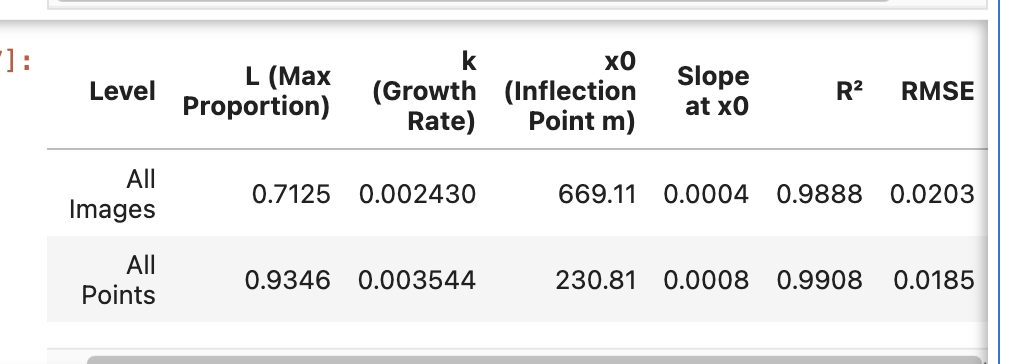

### Negative Exponential

In [ ]:
# ============================================================
# CHUNK 1: Fit & Plot the Negative Exponential Curves
# ============================================================

def neg_exp_func(x, a, b):
    return a * (1 - np.exp(-b * x))

def neg_exp_derivative(x, a, b):
    return a * b * np.exp(-b * x)

def fit_neg_exp(sub_df):
    x = sub_df["Distance (m)"].values
    y = sub_df["Proportion"].values
    popt, pcov = curve_fit(neg_exp_func, x, y, p0=[1, 0.001], maxfev=5000)  # keep pcov
    return popt, pcov, x, y

# --- Prepare plot data ---
fit_data = {
    "All Images": {"color": "#e4c8b0", "label": "SVI Images"},
    "All Points": {"color": "#7b5032", "label": "Waste Points"},
}

x_fit = np.linspace(0, 2000, 300)
plt.figure(figsize=(8, 8))

for level, style in fit_data.items():
    sub_df = plot_df[plot_df["Level"] == level].copy()
    (a, b), pcov, x_data, y_data = fit_neg_exp(sub_df)

    y_fit = neg_exp_func(x_fit, a, b)
    x_half = np.log(2) / b
    y_half = neg_exp_func(x_half, a, b)

    # R²
    y_pred = neg_exp_func(x_data, a, b)
    ss_res = np.sum((y_data - y_pred) ** 2)
    ss_tot = np.sum((y_data - np.mean(y_data)) ** 2)
    r_squared = 1 - (ss_res / ss_tot)

    sns.scatterplot(x=x_data, y=y_data, label=f"Observed ({style['label']})", color=style["color"], alpha=0.6)
    plt.plot(x_fit, y_fit, label=f"Neg. Exp. Fit ({style['label']})", color=style["color"], linewidth=2)
    plt.scatter(x_half, y_half, color=style["color"], edgecolor='black', s=80, zorder=5)
    plt.axvline(x_half, color=style["color"], linestyle='--', alpha=0.5)

    # Annotation: R² + asymptote a
    plt.text(
        x_half + 30, y_half - 0.08,
        f"{style['label']}\n$R^2$ = {r_squared:.3f}\n$a$ = {a:.3f}",
        color=style["color"],
        fontsize=14
    )

# --- Final plot settings ---
plt.title("Negative Exponential Fit \n Waste Proximity to Urban Poor", fontsize=20)
plt.xlabel("Distance to Urban Poor Boundary (m)", fontsize=16)
plt.ylabel("Proportion Within Distance", fontsize=16)
plt.ylim(0, 1.05)
plt.xlim(0, 2000)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=14, title='SVI Images vs Waste Points')
plt.tight_layout()
plt.savefig(DATA_DIR / "Figure/NegExp_Images_vs_AllPoints.png", dpi=600, bbox_inches='tight', transparent=True)
plt.show()

In [ ]:
# ============================================================
# CHUNK 2: Derivative Plot — x½, slope, and p-value
# ============================================================

from scipy import stats

label_map = {
    "All Points": "Waste Points",
    "All Images": "SVI Images"
}

fitted_models = {}
for level in ["All Points", "All Images"]:
    sub_df = plot_df[plot_df["Level"] == level].copy()
    (a, b), pcov, x_data, y_data = fit_neg_exp(sub_df)

    # P-value for b (the decay rate — most important parameter)
    perr = np.sqrt(np.diag(pcov))       # standard errors
    dof = len(x_data) - 2               # degrees of freedom (2 params: a, b)
    t_stat_b = b / perr[1]              # t-statistic for b
    p_val_b = 2 * (1 - stats.t.cdf(np.abs(t_stat_b), df=dof))  # two-tailed

    fitted_models[label_map[level]] = {"a": a, "b": b, "p_val_b": p_val_b}

x_fit = np.linspace(0, 2000, 300)
plt.figure(figsize=(10, 5))

colors = {
    "Waste Points": "#7b5032",
    "SVI Images":   "#e4c8b0"
}

for level, params in fitted_models.items():
    a, b, p_val_b = params["a"], params["b"], params["p_val_b"]

    y_derivative = neg_exp_derivative(x_fit, a, b)
    peak_slope = neg_exp_derivative(0, a, b)
    x_half = np.log(2) / b
    y_at_half = neg_exp_derivative(x_half, a, b)

    # Format p-value
    p_str = "< 0.001" if p_val_b < 0.001 else f"= {p_val_b:.3f}"

    plt.plot(x_fit, y_derivative, label=f"{level} ($x_{{½}}$ ≈ {x_half:.0f} m)", color=colors[level])
    plt.axvline(x_half, color=colors[level], linestyle='--', alpha=0.6)

    annotation = (
        f"{level}\n"
        f"$x_{{½}}$ = {x_half:.0f} m\n"
        f"Slope = {peak_slope * 1e2:.2f} ×10$^{{-2}}$\n"
        f"$p$ {p_str}"
    )
    plt.text(
        x_half + 20, y_at_half,
        annotation,
        fontsize=14,
        color=colors[level],
        ha='left',
        va='bottom'
    )

plt.title("Neg. Exponential Derivative:\nRate of Change vs. Distance to Urban Poor", fontsize=20)
plt.xlabel("Distance to Urban Poor Boundary (m)", fontsize=16)
plt.ylabel("Change in Proportion per Meter", fontsize=16)
plt.xlim(0, 2000)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=14, title='SVI Images vs Waste Points')
plt.tight_layout()
plt.savefig(DATA_DIR / "Figure/NegExp_derivative.png", dpi=600, bbox_inches='tight', transparent=True)
plt.show()

In [ ]:
from scipy import stats

# ============================================================
# PARAMETER SUMMARY TABLE — Negative Exponential Model
# ============================================================

print("=" * 65)
print("Negative Exponential Model: a * (1 - exp(-b * x))")
print("=" * 65)

for level in ["All Points", "All Images"]:
    sub_df = plot_df[plot_df["Level"] == level].copy()
    (a, b), pcov, x_data, y_data = fit_neg_exp(sub_df)

    # --- Fitted values ---
    y_pred = neg_exp_func(x_data, a, b)

    # --- R² ---
    ss_res = np.sum((y_data - y_pred) ** 2)
    ss_tot = np.sum((y_data - np.mean(y_data)) ** 2)
    r_squared = 1 - (ss_res / ss_tot)

    # --- RMSE ---
    rmse = np.sqrt(np.mean((y_data - y_pred) ** 2))

    # --- Standard errors & p-values ---
    perr = np.sqrt(np.diag(pcov))
    dof = len(x_data) - 2
    t_stat_a = a / perr[0]
    t_stat_b = b / perr[1]
    p_val_a = 2 * (1 - stats.t.cdf(np.abs(t_stat_a), df=dof))
    p_val_b = 2 * (1 - stats.t.cdf(np.abs(t_stat_b), df=dof))

    # --- Derived values ---
    x_half = np.log(2) / b
    peak_slope = neg_exp_derivative(0, a, b)

    # --- Label ---
    label = "Waste Points" if level == "All Points" else "SVI Images"

    print(f"\n{'─' * 65}")
    print(f"  Dataset        : {label}")
    print(f"{'─' * 65}")
    print(f"  {'Parameter':<30} {'Value':<15} {'Std Error':<12} {'p-value'}")
    print(f"  {'─'*28} {'─'*13} {'─'*10} {'─'*10}")
    print(f"  {'Asymptote (a)':<30} {a:<15.4f} {perr[0]:<12.4f} {'< 0.001' if p_val_a < 0.001 else f'{p_val_a:.4f}'}")
    print(f"  {'Decay rate (b)':<30} {b:<15.6f} {perr[1]:<12.6f} {'< 0.001' if p_val_b < 0.001 else f'{p_val_b:.4f}'}")
    print(f"  {'─'*28} {'─'*13} {'─'*10} {'─'*10}")
    print(f"  {'R²':<30} {r_squared:.4f}")
    print(f"  {'RMSE':<30} {rmse:.4f}")
    print(f"  {'Half-life x½ (m)':<30} {x_half:.1f}")
    print(f"  {'Peak slope at x=0 (×10⁻²)':<30} {peak_slope * 1e2:.4f}")
    print(f"  {'Sample size (n)':<30} {len(x_data)}")

print(f"\n{'=' * 65}")

In [ ]:
from scipy import stats
from docx import Document
from docx.shared import Pt, RGBColor
from docx.enum.text import WD_ALIGN_PARAGRAPH
from docx.enum.table import WD_ALIGN_VERTICAL
from docx.oxml.ns import qn
from docx.oxml import OxmlElement

# ============================================================
# COMPUTE ALL PARAMETERS
# ============================================================

results = {}
for level in ["All Points", "All Images"]:
    sub_df = plot_df[plot_df["Level"] == level].copy()
    (a, b), pcov, x_data, y_data = fit_neg_exp(sub_df)

    y_pred = neg_exp_func(x_data, a, b)

    # R² and RMSE
    ss_res = np.sum((y_data - y_pred) ** 2)
    ss_tot = np.sum((y_data - np.mean(y_data)) ** 2)
    r_squared = 1 - (ss_res / ss_tot)
    rmse = np.sqrt(np.mean((y_data - y_pred) ** 2))

    # Standard errors and p-values
    perr = np.sqrt(np.diag(pcov))
    dof = len(x_data) - 2
    p_val_a = 2 * (1 - stats.t.cdf(np.abs(a / perr[0]), df=dof))
    p_val_b = 2 * (1 - stats.t.cdf(np.abs(b / perr[1]), df=dof))

    # Derived
    x_half = np.log(2) / b
    peak_slope = neg_exp_derivative(0, a, b)

    label = "Waste Points" if level == "All Points" else "SVI Images"
    results[label] = {
        "a": a, "a_se": perr[0], "p_a": p_val_a,
        "b": b, "b_se": perr[1], "p_b": p_val_b,
        "r2": r_squared, "rmse": rmse,
        "x_half": x_half,
        "peak_slope": peak_slope,
        "n": len(x_data)
    }

# ============================================================
# BUILD WORD TABLE
# ============================================================

doc = Document()

# --- Title ---
title = doc.add_paragraph("Table S3. Negative Exponential Model Parameter Estimates")
title.style = doc.styles["Normal"]
title.runs[0].bold = True
title.runs[0].font.size = Pt(11)

subtitle = doc.add_paragraph("Model: Proportion = a × (1 − exp(−b × Distance))")
subtitle.runs[0].italic = True
subtitle.runs[0].font.size = Pt(10)

doc.add_paragraph("")  # spacer

# --- Table structure ---
# Rows: header + 8 parameters + 1 blank separator
headers = ["Parameter", "Waste Points", "SVI Images"]
rows = [
    ("Asymptote (a)",               "a",          ".4f",  False),
    ("  SE",                        "a_se",       ".4f",  True),
    ("  p-value",                   "p_a",        "p",    True),
    ("Decay rate (b)",              "b",          ".6f",  False),
    ("  SE",                        "b_se",       ".6f",  True),
    ("  p-value",                   "p_b",        "p",    True),
    ("R²",                          "r2",         ".4f",  False),
    ("RMSE",                        "rmse",       ".4f",  False),
    ("Half-life x½ (m)",            "x_half",     ".1f",  False),
    ("Peak slope at x=0 (×10⁻²)",  "peak_slope", "s",    False),
    ("Sample size (n)",             "n",          "d",    False),
]

table = doc.add_table(rows=1 + len(rows), cols=3)
table.style = "Table Grid"

def fmt(val, fmt_str):
    if fmt_str == "p":
        return "< 0.001" if val < 0.001 else f"{val:.4f}"
    elif fmt_str == "s":
        return f"{val * 1e2:.4f}"
    elif fmt_str == "d":
        return str(int(val))
    else:
        return f"{val:{fmt_str}}"

def set_cell(cell, text, bold=False, italic=False, indent=False, bg_color=None):
    cell.vertical_alignment = WD_ALIGN_VERTICAL.CENTER
    para = cell.paragraphs[0]
    para.alignment = WD_ALIGN_PARAGRAPH.CENTER
    run = para.add_run(("    " if indent else "") + text)
    run.bold = bold
    run.italic = italic
    run.font.size = Pt(10)
    if bg_color:
        tc = cell._tc
        tcPr = tc.get_or_add_tcPr()
        shd = OxmlElement("w:shd")
        shd.set(qn("w:val"), "clear")
        shd.set(qn("w:color"), "auto")
        shd.set(qn("w:fill"), bg_color)
        tcPr.append(shd)

# --- Header row ---
hdr_cells = table.rows[0].cells
for i, h in enumerate(headers):
    set_cell(hdr_cells[i], h, bold=True, bg_color="D9D9D9")

# --- Data rows ---
for i, (label, key, fmt_str, is_indent) in enumerate(rows):
    row_cells = table.rows[i + 1].cells

    # Left-align parameter name
    row_cells[0].paragraphs[0].alignment = WD_ALIGN_PARAGRAPH.LEFT
    run = row_cells[0].paragraphs[0].add_run(label)
    run.font.size = Pt(10)
    run.italic = is_indent  # indent rows shown in italic

    for j, dataset in enumerate(["Waste Points", "SVI Images"]):
        val = results[dataset][key]
        set_cell(row_cells[j + 1], fmt(val, fmt_str), indent=False)

# --- Note ---
doc.add_paragraph("")
note = doc.add_paragraph(
    "Note: SE = standard error. p-values derived from two-tailed t-test. "
    "x½ = half-life distance at which 50% of the asymptote is reached. "
    "Peak slope reported as rate of change per metre × 10⁻² at x = 0."
)
note.runs[0].font.size = Pt(9)
note.runs[0].italic = True

# --- Save ---
out_path = DATA_DIR / "Figure/Table_S3_NegExp_Parameters.docx"
doc.save(out_path)
print(f"Table saved to: {out_path}")

### Power-Law

In [ ]:
# ============================================================
# CHUNK 1: Fit & Plot the Power-Law Curves
# ============================================================

def power_law_func(x, a, b):
    return a * np.power(x, b)

def power_law_derivative(x, a, b):
    return a * b * np.power(x, b - 1)

def fit_power_law(sub_df):
    x = sub_df["Distance (m)"].values
    y = sub_df["Proportion"].values
    mask = x > 0
    x, y = x[mask], y[mask]
    popt, _ = curve_fit(power_law_func, x, y, p0=[0.1, 0.5], maxfev=5000)
    return popt, x, y

label_map = {
    "All Images": "SVI Images",
    "All Points": "Waste Points"
}

fit_data = {
    "All Images": {"color": "#e4c8b0", "label": "SVI Images"},
    "All Points": {"color": "#7b5032", "label": "Waste Points"},
}

x_fit = np.linspace(1, 2000, 300)
plt.figure(figsize=(8, 8))

for level, style in fit_data.items():
    sub_df = plot_df[plot_df["Level"] == level].copy()
    (a, b), x_data, y_data = fit_power_law(sub_df)

    y_fit = power_law_func(x_fit, a, b)
    y_pred = power_law_func(x_data, a, b)

    # R² and RMSE
    ss_res = np.sum((y_data - y_pred) ** 2)
    ss_tot = np.sum((y_data - np.mean(y_data)) ** 2)
    r_squared = 1 - (ss_res / ss_tot)
    rmse = np.sqrt(np.mean((y_data - y_pred) ** 2))

    sns.scatterplot(x=x_data, y=y_data, label=f"Observed ({style['label']})", color=style["color"], alpha=0.6)
    plt.plot(x_fit, y_fit, label=f"Power-Law Fit ({style['label']})", color=style["color"], linewidth=2)

    # Annotate at x=1200 to avoid overlap
    x_ann = 1200
    y_ann = power_law_func(x_ann, a, b)
    plt.text(
        x_ann, y_ann - 0.08,
        f"{style['label']}\n$R^2$ = {r_squared:.3f}\nRMSE = {rmse:.4f}",
        color=style["color"],
        fontsize=14
    )

plt.title("Power-Law Fit of Waste Proximity to Urban Poor", fontsize=20)
plt.xlabel("Distance to Urban Poor Boundary (m)", fontsize=16)
plt.ylabel("Proportion Within Distance", fontsize=16)
plt.ylim(0, 1.05)
plt.xlim(0, 2000)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=14, title='SVI Images vs Waste Points')
plt.tight_layout()
plt.savefig(DATA_DIR / "Figure/PowerLaw_Images_vs_AllPoints.png", dpi=600, bbox_inches='tight', transparent=True)
plt.show()

In [ ]:
# ============================================================
# CHUNK 2: Derivative Plot — no arbitrary vertical lines
# ============================================================

fitted_models = {}
for level in ["All Points", "All Images"]:
    sub_df = plot_df[plot_df["Level"] == level].copy()
    (a, b), *_ = fit_power_law(sub_df)
    fitted_models[label_map[level]] = {"a": a, "b": b}

x_fit = np.linspace(1, 2000, 300)
plt.figure(figsize=(10, 5))

colors = {
    "Waste Points": "#7b5032",
    "SVI Images":   "#e4c8b0"
}

# Annotate at different x positions to avoid overlap
ann_x = {"Waste Points": 600, "SVI Images": 200}

for level, params in fitted_models.items():
    a, b = params["a"], params["b"]

    y_derivative = power_law_derivative(x_fit, a, b)

    # Slope at x=50m — early rapid-change zone, avoids singularity
    slope_at_50 = power_law_derivative(50, a, b)
    y_ann = power_law_derivative(ann_x[level], a, b)

    plt.plot(x_fit, y_derivative, label=f"{level} (b ≈ {b:.3f})", color=colors[level], linewidth=2)

    # Annotate: b and slope at 50m
    annotation = (
        f"{level}\n"
        f"$b$ = {b:.3f}\n"
        f"Slope@50m = {slope_at_50 * 1e2:.2f} ×10$^{{-2}}$"
    )
    plt.text(
        ann_x[level], y_ann,
        annotation,
        fontsize=12,
        color=colors[level],
        ha='left',
        va='bottom'
    )

plt.title("Power-Law Derivative: Rate of Change vs. Distance to Urban Poor", fontsize=20)
plt.xlabel("Distance to Urban Poor Boundary (m)", fontsize=16)
plt.ylabel("Change in Proportion per Meter", fontsize=16)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=14, title='SVI Images vs Waste Points')
plt.tight_layout()
plt.savefig(DATA_DIR / "Figure/PowerLaw_derivative.png", dpi=600, bbox_inches='tight', transparent=True)
plt.show()

## Others

## Inside/outside Slum (Spatial Inequality Metrics)

In [ ]:
# waste_Nairobi_gdf[waste_Nairobi_gdf['distance_to_slum']==0]
waste_Nairobi_gdf['in_slum'] = waste_Nairobi_gdf['distance_to_slum'].apply(lambda x: 'Y' if x == 0 else 'N')
waste_Nairobi_gdf

In [ ]:
# Convert distance to km
waste_Nairobi_gdf["dist_km"] = waste_Nairobi_gdf["distance_to_slum"] / 1000
ALLSVI_Nairobi_gdf["dist_km"] = ALLSVI_Nairobi_gdf["distance_to_slum"] / 1000

# Style settings
sns.set_theme(style="whitegrid", font_scale=1.4)

plt.figure(figsize=(12, 6))

# KDE plots
sns.kdeplot(
    data=waste_Nairobi_gdf, 
    x="dist_km", 
    fill=True, 
    linewidth=1.2,
    color="#7b5032",
    alpha=0.1,
    label="Waste Pile Locations",
)

sns.kdeplot(
    data=ALLSVI_Nairobi_gdf, 
    x="dist_km", 
    fill=True, 
    linewidth=1.2,
    color="#e4c8b0",
    alpha=0.6,
    label="All SVI Points",
)

# Labels & title
plt.xlabel("Distance to Urban Poor Settlements Boundary (km)")
plt.ylabel("Density")
plt.title("Distance to Urban Poor Settlements Boundary for Different Point Types")

# Legend
plt.legend(title="Point Category")

# Tight layout
plt.tight_layout()
plt.savefig(DATA_DIR / 'Figure/distance_KDE.png', dpi=600, bbox_inches='tight', transparent=True)
plt.show()

In [ ]:
# Extract the distance variables as 1-D arrays
dist_waste = waste_Nairobi_gdf["dist_km"].dropna()
dist_all = ALLSVI_Nairobi_gdf["dist_km"].dropna()

# Two-sample KS test
ks_stat, p_value = ks_2samp(dist_waste, dist_all)

print(f"KS Statistic (D): {ks_stat:.4f}")
print(f"P-value: {p_value:.4g}")

In [ ]:
import numpy as np

# Convert distance to km
waste_Nairobi_gdf["dist_km"] = waste_Nairobi_gdf["distance_to_slum"] / 1000
ALLSVI_Nairobi_gdf["dist_km"] = ALLSVI_Nairobi_gdf["distance_to_slum"] / 1000

# Style settings
sns.set_theme(style="whitegrid", font_scale=1.4)
plt.figure(figsize=(12, 6))

# --- Compute CDFs manually ---
for df, color, label in [
    (waste_Nairobi_gdf, "#7b5032", "Waste Pile Locations"),
    (ALLSVI_Nairobi_gdf, "#e4c8b0", "All SVI Points"),
]:
    sorted_dist = np.sort(df["dist_km"].dropna().values)
    cdf = np.arange(1, len(sorted_dist) + 1) / len(sorted_dist)
    plt.plot(sorted_dist, cdf, color=color, label=label, linewidth=2)
    plt.fill_between(sorted_dist, cdf, alpha=0.2, color=color)

# --- Reference lines ---
for pct, ls in [(0.5, '--'), (0.9, ':')]:
    plt.axhline(pct, color='gray', linestyle=ls, alpha=0.6,
                label=f"{int(pct*100)}th percentile")

# Labels & title
plt.xlabel("Distance to Urban Poor Settlements Boundary (km)", fontsize=16)
plt.ylabel("Cumulative Proportion", fontsize=16)
plt.title("Cumulative Distribution of Distance to\nUrban Poor Settlement Boundaries", fontsize=20)
plt.xlim(0, 2)
plt.ylim(0, 1.05)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(title="Point Category", fontsize=14, title_fontsize=13)
plt.tight_layout()
plt.savefig(DATA_DIR / 'Figure/distance_CDF.png', dpi=600, bbox_inches='tight', transparent=True)
plt.show()

In [ ]:
# Convert distance to km
waste_Nairobi_gdf["dist_km"] = waste_Nairobi_gdf["distance_to_slum"] / 1000
ALLSVI_Nairobi_gdf["dist_km"] = ALLSVI_Nairobi_gdf["distance_to_slum"] / 1000

# Style settings
sns.set_theme(style="whitegrid", font_scale=1.4)
plt.figure(figsize=(12, 6))

# --- Waste Points ---
sorted_dist_w = np.sort(waste_Nairobi_gdf["dist_km"].dropna().values)
cdf_w = np.arange(1, len(sorted_dist_w) + 1) / len(sorted_dist_w)
plt.plot(sorted_dist_w, cdf_w, color="#7b5032", label="Waste Pile Locations", linewidth=2)
plt.fill_between(sorted_dist_w, cdf_w, alpha=0.1, color="#7b5032")

# --- SVI Points ---
sorted_dist_s = np.sort(ALLSVI_Nairobi_gdf["dist_km"].dropna().values)
cdf_s = np.arange(1, len(sorted_dist_s) + 1) / len(sorted_dist_s)
plt.plot(sorted_dist_s, cdf_s, color="#e4c8b0", label="All SVI Points", linewidth=2)
plt.fill_between(sorted_dist_s, cdf_s, alpha=0.6, color="#e4c8b0")

# --- Reference lines ---
plt.axhline(0.5, color='gray', linestyle='--', alpha=0.6, label="50th percentile")
plt.axhline(0.9, color='gray', linestyle=':', alpha=0.6, label="90th percentile")

# Labels & title
plt.xlabel("Distance to Urban Poor Settlements Boundary (km)", fontsize=16)
plt.ylabel("Cumulative Proportion", fontsize=16)
plt.title("Cumulative Distribution of Distance to\nUrban Poor Settlement Boundaries", fontsize=20)
plt.xlim(0, 2)
plt.ylim(0, 1.05)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(title="Point Category", fontsize=14, title_fontsize=13)
plt.tight_layout()
plt.savefig(DATA_DIR / 'Figure/distance_CDF.png', dpi=600, bbox_inches='tight', transparent=True)
plt.show()

In [ ]:
# Categorize points into four mutually exclusive groups per your data:
def categorize_point(row):
    if row['in_slum'] == 'Y':
        return "Within Urban Poor"
    elif row['distance_to_slum'] <= 250:
        return "0-250m buffer"
    elif row['distance_to_slum'] <= 500:
        return "250-500m buffer"
    else:
        return ">500m outside"

waste_Nairobi_gdf["distance_category"] = waste_Nairobi_gdf.apply(categorize_point, axis=1)

# Group by your cluster column (HDB_cluster) and new distance_category, then count
prop_df = (
    waste_Nairobi_gdf.groupby(['HDB_cluster', "distance_category"])
    .size()
    .unstack(fill_value=0)
)

# Convert counts to proportions within each cluster
prop_df = prop_df.div(prop_df.sum(axis=1), axis=0)

# Ensure all expected categories are columns, add any missing with 0
for cat in ["Within Urban Poor", "0-250m buffer", "250-500m buffer", ">500m outside"]:
    if cat not in prop_df.columns:
        prop_df[cat] = 0

# Reorder columns to desired stack order
prop_df = prop_df[["Within Urban Poor", "0-250m buffer", "250-500m buffer", ">500m outside"]]

# Sort by "Within Slum" proportion descending (optional)
prop_df = prop_df.sort_values(by="Within Urban Poor", ascending=False)

# Colors for the stacks (feel free to change)
colors = ["#7b5032", "#ad8260", "#e4c8b0", "#fbf5ee"]  # dark brown to light gray

# Plot stacked bar chart
fig, ax = plt.subplots(figsize=(12, 5), constrained_layout=True)

prop_df.plot(
    kind='bar',
    stacked=True,
    color=colors,
    ax=ax
)

# Titles and labels
ax.set_title("Cluster Composition by Distance to Slum Boundary", pad=20)
ax.set_ylabel("Proportion of Points")
ax.set_xlabel("HDBSCAN Cluster Label")
ax.set_ylim(0, 1)
ax.yaxis.grid(True, linestyle='--', alpha=0.3)

# Format y-axis ticks as percentages
yticks = ax.get_yticks()
ax.set_yticklabels(['{:.0%}'.format(y) for y in yticks])

# Legend
ax.legend(title="Distance Category", loc='upper right')

plt.savefig(DATA_DIR / 'Figure/Cluster_Composition_By_Distance_Category.png', dpi=600, bbox_inches='tight', transparent=True)
plt.show()

In [ ]:
# Sum the proportions of "Within Slum" and "0-250m buffer" for each cluster
within_250m = prop_df["Within Urban Poor"] + prop_df["0-250m buffer"]

# Count how many clusters have 50% or more of points in this range
num_clusters_50pct_within250 = (within_250m >= 0.5).sum()

# Optionally: compute total number of clusters (excluding noise if needed)
total_clusters = len(prop_df)

# And the proportion:
proportion_clusters_50pct_within250 = num_clusters_50pct_within250 / total_clusters

# Print results
print(f"{num_clusters_50pct_within250} out of {total_clusters} clusters ({proportion_clusters_50pct_within250:.0%}) have ≥50% of their points within 250m of a slum.")


In [ ]:
# Sum proportions of points within 500m (i.e., slum + 0–250m + 250–500m)
within_500m = (
    prop_df["Within Urban Poor"] +
    prop_df["0-250m buffer"] +
    prop_df["250-500m buffer"]
)

# Count clusters where ≥50% of points are within 500m
num_clusters_50pct_within500 = (within_500m >= 0.5).sum()

# Total number of clusters (same as before)
total_clusters = len(prop_df)

# Proportion of such clusters
proportion_clusters_50pct_within500 = num_clusters_50pct_within500 / total_clusters

# Print results
print(f"{num_clusters_50pct_within500} out of {total_clusters} clusters ({proportion_clusters_50pct_within500:.0%}) have ≥50% of their points within 500m of a slum.")

In [ ]:
a = 0.59
b = 0.0003
target_proportion = 0.25

# Solve for distance
x_at_25_percent = -np.log(target_proportion / a) / b
print(f"Distance where 25% of points are within: {x_at_25_percent:.0f} meters")

In [ ]:
waste_Nairobi_gdf

In [ ]:
# Count points per cluster, split by inside/outside
cluster_counts = waste_Nairobi_gdf.groupby(['HDB_cluster', "in_slum"]).size().unstack(fill_value=0)


In [ ]:
# Mark each point as inside or outside
waste_Nairobi_gdf["in_slum"] = waste_Nairobi_gdf.index.isin(waste_in_slums.index)

# Count points per cluster, split by inside/outside
cluster_counts = waste_Nairobi_gdf.groupby(['HDB_cluster', "in_slum"]).size().unstack(fill_value=0)

# Rename for clarity
cluster_counts.columns = ["Outside Slums", "Inside Slums"]
cluster_counts["Total"] = cluster_counts.sum(axis=1)

# Mean sizes
mean_size_inside = cluster_counts[cluster_counts["Inside Slums"] > 0]["Total"].mean()
mean_size_outside = cluster_counts[cluster_counts["Inside Slums"] == 0]["Total"].mean()

# Median sizes
median_size_inside = cluster_counts[cluster_counts["Inside Slums"] > 0]["Total"].median()
median_size_outside = cluster_counts[cluster_counts["Inside Slums"] == 0]["Total"].median()

# Print results
print(f"Average cluster size (with any part in slum): {mean_size_inside:.2f} points")
print(f"Average cluster size (fully outside slums): {mean_size_outside:.2f} points")
print(f"Median cluster size (with any part in slum): {median_size_inside:.2f} points")
print(f"Median cluster size (fully outside slums): {median_size_outside:.2f} points")

In [ ]:
# Prepare data
cluster_counts["Cluster Type"] = cluster_counts["Inside Slums"].apply(
    lambda x: "Inside Slums" if x > 0 else "Outside Slums"
)
df_violin = cluster_counts[["Total", "Cluster Type"]].reset_index()

# Color palette
palette = {
    "Inside Slums": "#ac8260",
    "Outside Slums": "#ebdbce"
}

# Compute means
means = df_violin.groupby("Cluster Type")["Total"].mean()

# Count clusters
counts = df_violin["Cluster Type"].value_counts().to_dict()

# Start plot
fig, ax = plt.subplots(figsize=(12, 8))

sns.violinplot(
    data=df_violin,
    x="Cluster Type",
    y="Total",
    hue="Cluster Type",
    palette=palette,
    inner="box",
    cut=0,
    legend=False,
    ax=ax
)

# Define how wide each short mean line should be
line_width = 0.4  # Set width of line around violin center
for artist in ax.collections:
    artist.set_edgecolor("none")
    
for i, cluster_type in enumerate(["Inside Slums", "Outside Slums"]):
    y_mean = means[cluster_type]
    
    # Plot a short line centered at i
    x_start = i - line_width / 2
    x_end = i + line_width / 2
    ax.plot(
        [x_start, x_end],
        [y_mean, y_mean],
        linestyle="--",
        # color=palette[cluster_type],
        color = '#112721',
        linewidth=1.5
    )
    
    # Add text label just above the line
    ax.text(
        i, y_mean + 1,
        f"Mean = {y_mean:.1f}",
        ha="center",
        va="bottom",
        fontsize=14,
        color = '#112721',
        # color=palette[cluster_type]
    )

# Add counts under violins
for i, cluster_type in enumerate(["Inside Slums", "Outside Slums"]):
    count = counts.get(cluster_type, 0)
    ax.text(i, -0.05 * df_violin["Total"].max(), f"n = {count}", ha="center", va="top", fontsize=14)


# Compute mean cluster size per group (still using mean; use median if needed)
means = df_violin.groupby("Cluster Type")["Total"].mean()

# Compute mean and IQR for each group
summary_stats = df_violin.groupby("Cluster Type")["Total"].agg(["mean", "quantile"])
summary_text_lines = []

# for cluster_type in ["With Any Parts Inside Slums", "Fully Outside Slums"]:
for cluster_type in ["Inside Slums", "Outside Slums"]:
    group_data = df_violin[df_violin["Cluster Type"] == cluster_type]["Total"]
    mean_val = group_data.mean()
    q25 = group_data.quantile(0.25)
    q75 = group_data.quantile(0.75)

    summary_text_lines.append(f"{cluster_type}")
    summary_text_lines.append(f"Mean: {mean_val:.1f}")
    summary_text_lines.append(f"25–75%: {q25:.0f}–{q75:.0f}")
    summary_text_lines.append("")  # Empty line between groups

# Create text box string
textstr = '\n'.join(summary_text_lines)

# Draw the box
props = dict(boxstyle='round', facecolor='white', edgecolor='gray', alpha=0.9)
ax.text(
    0.75, 0.9, textstr,
    transform=ax.transAxes,
    fontsize=14,
    verticalalignment='top',
    bbox=props
)

# Labels and cleanup
ax.set_title("Distribution of Cluster Sizes\nInside vs Outside Informal Settlements", pad=20)
ax.set_ylabel("Number of Points in Cluster")
ax.set_xlabel("Cluster Type")

ax.yaxis.grid(True, linestyle='--', alpha=0.3)
# ax.spines['top'].set_visible(False)
# ax.spines['right'].set_visible(False)
# plt.savefig(DATA_DIR / 'Figure/Cluster_violion.png', dpi=600, bbox_inches='tight', transparent=True)

plt.tight_layout()
plt.show()

In [ ]:
# Define exponential decay function
def decay_func(x, a, b):
    return a * np.exp(-b * x)

# True vs predicted
point_df = plot_df[plot_df["Level"] == "All Points"].copy()

y_true = point_df["Proportion"]
y_pred = decay_func(point_df["Distance (m)"], a, b)

r2 = r2_score(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))

print(f"R²: {r2:.3f}")
print(f"RMSE: {rmse:.3f}")

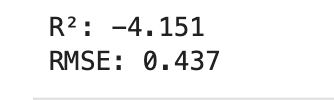